In [4]:
import sys
!{sys.executable} -m pip install pandas matplotlib requests openpyxl

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.8 MB 11.5 MB/s eta 0:00:01
   ----------------- ---------------------- 4.2/9.8 MB 10.7 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 10.7 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 10.3 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.2 MB 9.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.2 MB 7.9 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 8.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 7.8 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 7.4 MB/s  0:00:01
   ------------------------

In [12]:
!python clean.py

Sheets: ['Prices with taxes', 'Prices wo taxes', 'Consumption', 'VAT', 'Excise duties', 'Excise duties - components', 'Other Indirect Taxes']

Cleaning sheet: Prices with taxes
First rows of cleaned data:
        Date  CTR  ...  UK_price_with_tax_fuel_oil_2  UK_price_with_tax_LPG
0 2026-05-18  NaN  ...                           NaN                    NaN
1 2026-05-11  NaN  ...                           NaN                    NaN
2 2026-05-04  NaN  ...                           NaN                    NaN
3 2026-04-27  NaN  ...                           NaN                    NaN
4 2026-04-20  NaN  ...                           NaN                    NaN

[5 rows x 226 columns]

First 15 column names:
['Date', 'CTR', 'EU_price_with_tax_euro95', 'EU_price_with_tax_diesel', 'EU_price_with_tax_heEUing_oil', 'EU_price_with_tax_fuel_oil_1', 'EU_price_with_tax_fuel_oil_2', 'EU_price_with_tax_LPG', 'CTR.1', 'EUR_price_with_tax_euro95', 'EUR_price_with_tax_diesel', 'EUR_price_with_tax_heEURing_o

In [13]:
!python reshape.py


Reshaping file: prices_with_taxes_fuels_only.csv
         Date country fuel_type price_type  price_per_1000l
0  2026-05-18      EU    euro95   with_tax      1881.812172
1  2026-05-11      EU    euro95   with_tax      1873.931984
2  2026-05-04      EU    euro95   with_tax      1861.113719
3  2026-04-27      EU    euro95   with_tax      1841.515072
4  2026-04-20      EU    euro95   with_tax      1827.449889
5  2026-04-13      EU    euro95   with_tax      1853.723723
6  2026-04-06      EU    euro95   with_tax      1878.734029
7  2026-03-30      EU    euro95   with_tax      1871.508517
8  2026-03-23      EU    euro95   with_tax      1893.491227
9  2026-03-16      EU    euro95   with_tax      1837.926054
(64020, 5)
Long file saved as prices_with_taxes_long.csv

Reshaping file: prices_wo_taxes_fuels_only.csv
         Date country fuel_type price_type  price_per_1000l
0  2026-05-18      EU    euro95     wo_tax      1007.562916
1  2026-05-11      EU    euro95     wo_tax      1000.588406
2  20

In [16]:
!python merge_prices.py

Merged file saved as prices_merged.csv
         Date country fuel_type  ...  price_wo_tax  tax_amount  tax_share
0  2026-05-18      EU    euro95  ...   1007.562916  874.249256   0.464578
1  2026-05-11      EU    euro95  ...   1000.588406  873.343578   0.466049
2  2026-05-04      EU    euro95  ...    990.201487  870.912232   0.467952
3  2026-04-27      EU    euro95  ...    964.776282  876.738789   0.476096
4  2026-04-20      EU    euro95  ...    952.775236  874.674653   0.478631

[5 rows x 7 columns]
(64020, 7)


In [18]:
import os

for file in sorted(os.listdir()):
    print(file)

.ipynb_checkpoints
Untitled.ipynb
Weekly_Oil_Bulletin_Prices_History_maticni_4web.xlsx
__pycache__
analysis.py
clean.py
download.py
merge_prices.py
prices_merged.csv
prices_with_taxes_clean.csv
prices_with_taxes_fuels_only.csv
prices_with_taxes_long.csv
prices_wo_taxes_clean.csv
prices_wo_taxes_fuels_only.csv
prices_wo_taxes_long.csv
proof.ipynb
reshape.py
top10_euro95_latest.png
visualiations.py


In [19]:
import importlib
import merge_prices

importlib.reload(merge_prices)

merged = merge_prices.merge_price_files()
print(merged.head())

Merged file saved as prices_merged.csv
         Date country fuel_type  price_with_tax  price_wo_tax  tax_amount  \
0  2026-05-18      EU    euro95     1881.812172   1007.562916  874.249256   
1  2026-05-11      EU    euro95     1873.931984   1000.588406  873.343578   
2  2026-05-04      EU    euro95     1861.113719    990.201487  870.912232   
3  2026-04-27      EU    euro95     1841.515072    964.776282  876.738789   
4  2026-04-20      EU    euro95     1827.449889    952.775236  874.674653   

   tax_share  
0   0.464578  
1   0.466049  
2   0.467952  
3   0.476096  
4   0.478631  
(64020, 7)
         Date country fuel_type  price_with_tax  price_wo_tax  tax_amount  \
0  2026-05-18      EU    euro95     1881.812172   1007.562916  874.249256   
1  2026-05-11      EU    euro95     1873.931984   1000.588406  873.343578   
2  2026-05-04      EU    euro95     1861.113719    990.201487  870.912232   
3  2026-04-27      EU    euro95     1841.515072    964.776282  876.738789   
4  2026-04-2

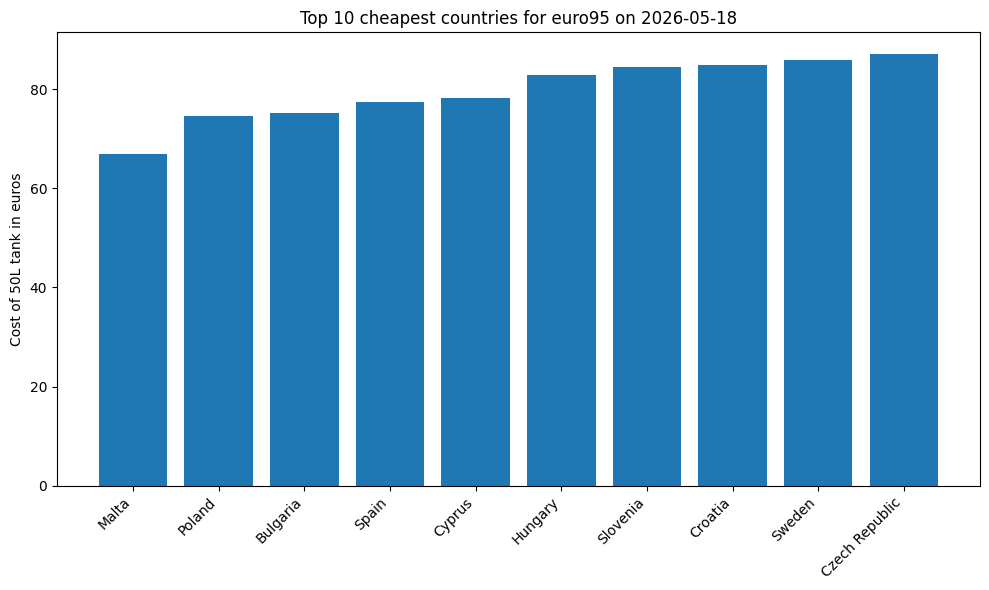

In [6]:
from visualiations import plot_top10_latest
plot_top10_latest("euro95", 50)

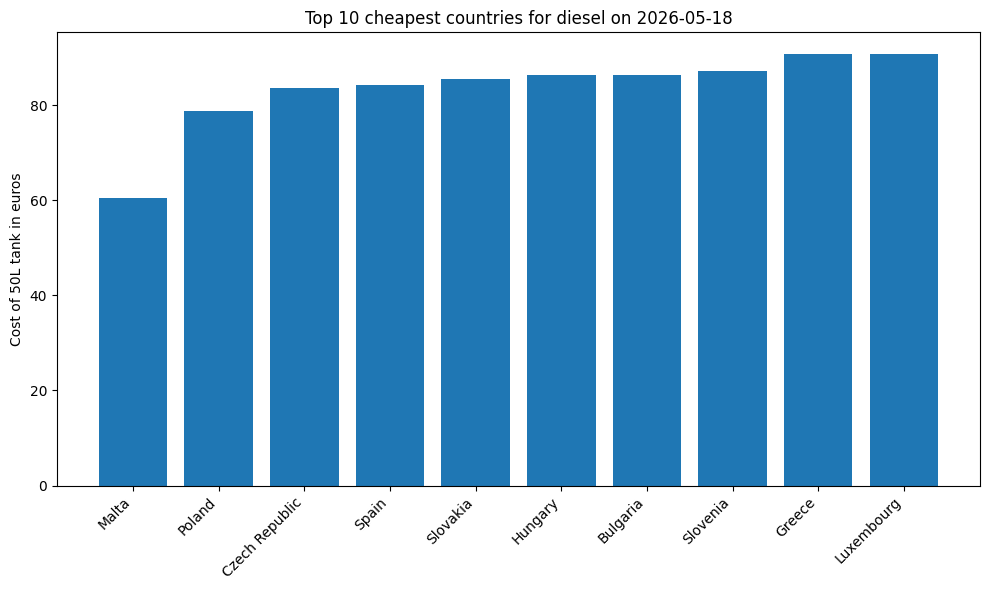

In [7]:
plot_top10_latest("diesel", 50)

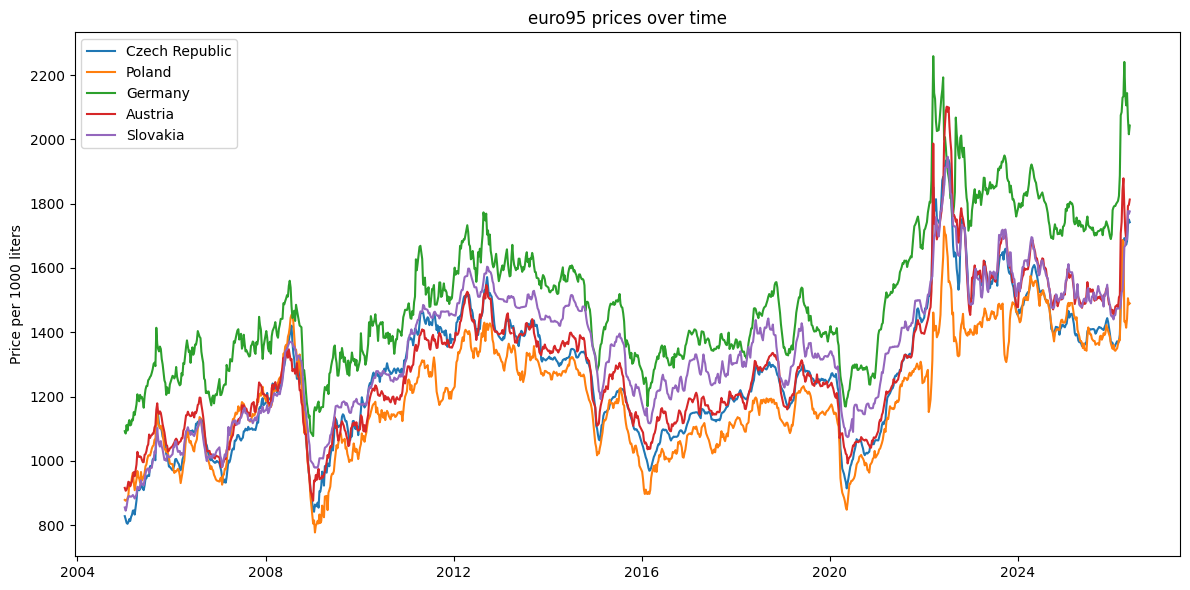

In [8]:
from visualiations import plot_selected_countries_trend
plot_selected_countries_trend(
    fuel_type="euro95",
    countries=["Czech Republic", "Poland", "Germany", "Austria", "Slovakia"]
)

In [20]:
import importlib
import tax_analysis
import tax_visualiations

importlib.reload(tax_analysis)
importlib.reload(tax_visualiations)

<module 'tax_visualiations' from 'C:\\Users\\ProBook\\Downloads\\project\\tax_visualiations.py'>

In [24]:
from tax_visualiations import plot_tax_share_latest, plot_tax_amount_latest, plot_with_vs_without_tax

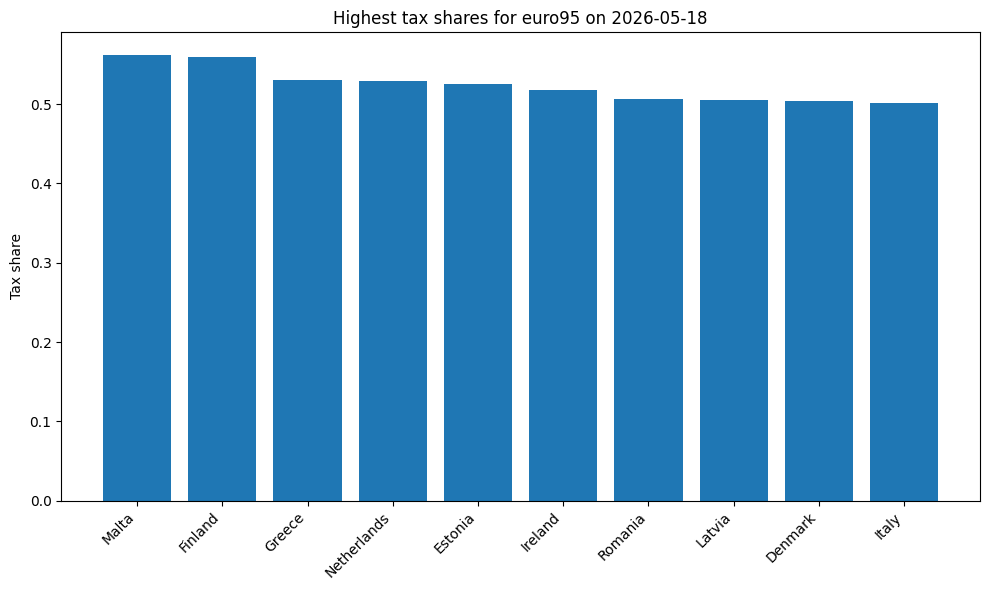

In [25]:
plot_tax_share_latest("euro95", 10)

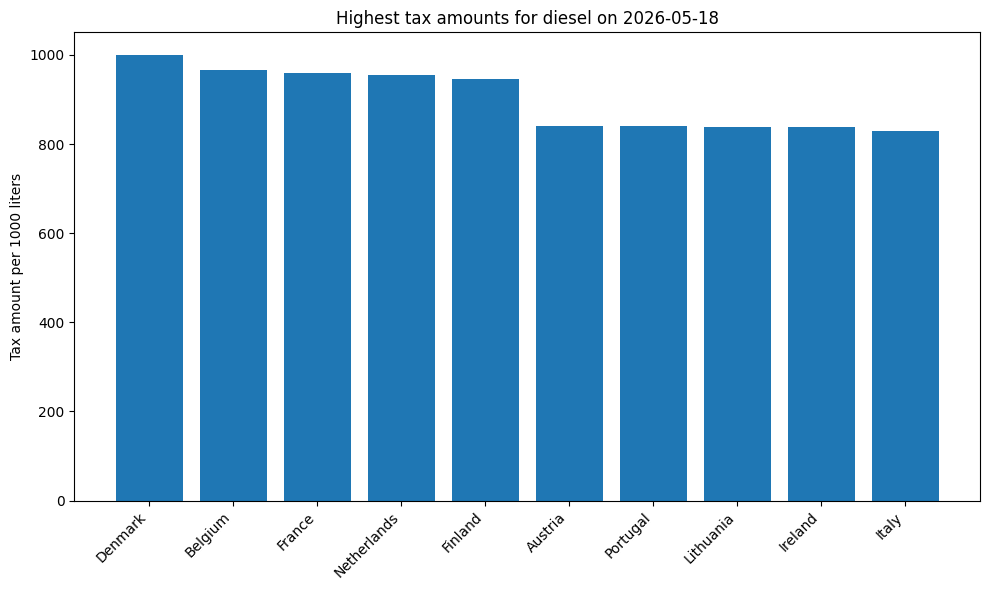

In [26]:
plot_tax_amount_latest("diesel", 10)

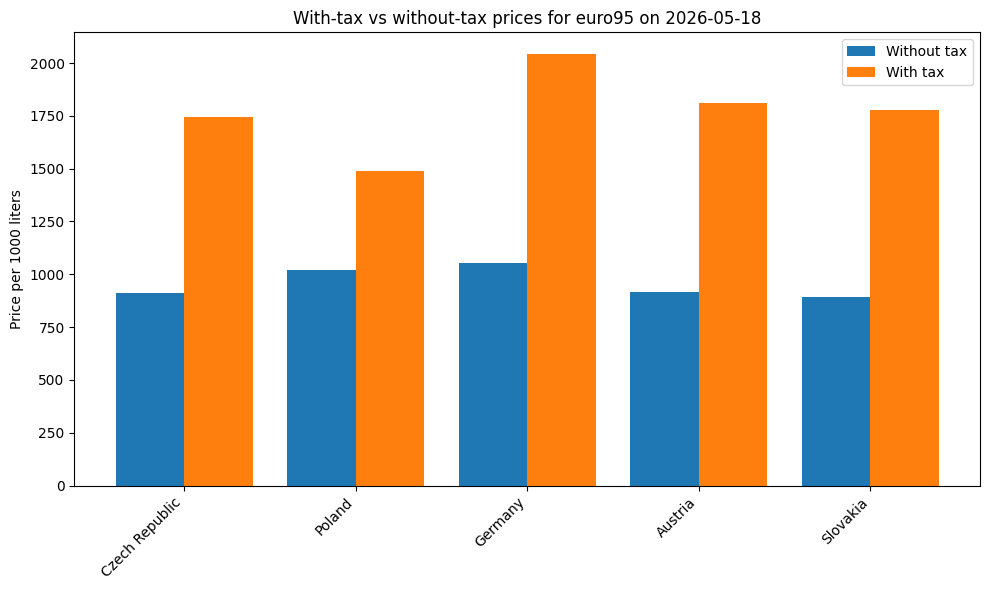

In [27]:
plot_with_vs_without_tax(
    fuel_type="euro95",
    countries=["Czech Republic", "Poland", "Germany", "Austria", "Slovakia"]
)

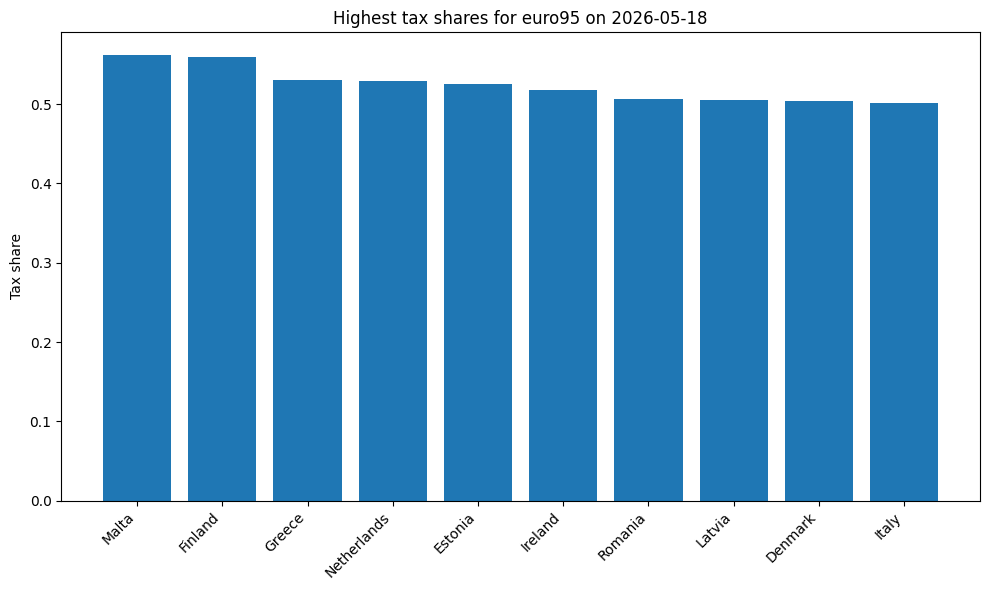

In [28]:
plot_tax_share_latest("euro95", 10)

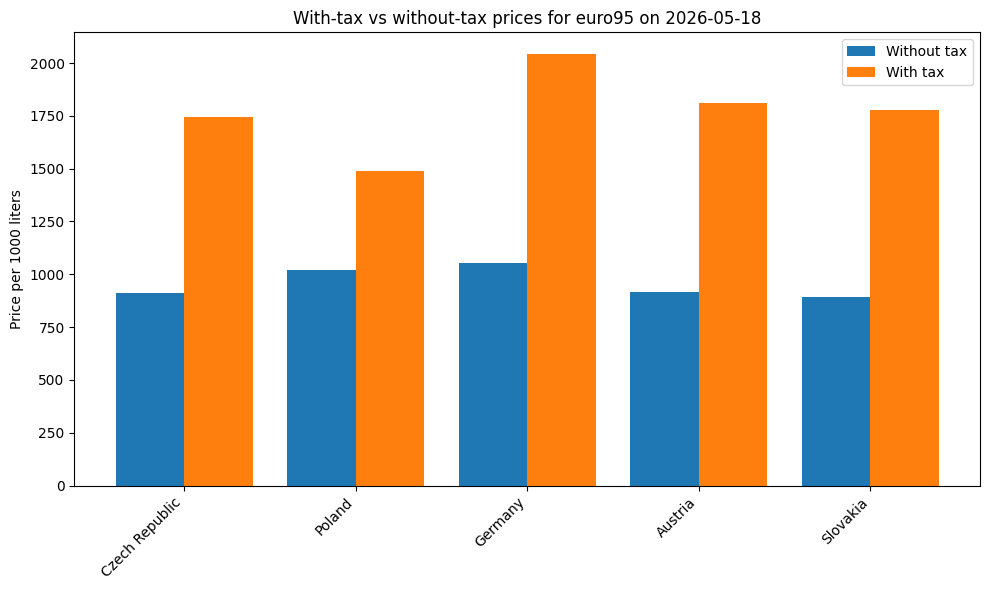

In [30]:
from tax_visualiations import plot_with_vs_without_tax

plot_with_vs_without_tax(
    fuel_type="euro95",
    countries=["Czech Republic", "Poland", "Germany", "Austria", "Slovakia"]
)